In [9]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.transforms import Affine2D


In [10]:
def open_class(zone):
  class_zone0 = Table.read(f"/Users/soguevaram/Desktop/Research/DESI/data/edr/classification/zone_{zone:02d}_classified.fits.gz").to_pandas()

  for col in class_zone0.columns:
    class_zone0[col] = class_zone0[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

  class_zone0_rand0 = class_zone0[(class_zone0['RANDITER'] == 0) & (class_zone0['ISDATA'] == True)]
  class_zone0_rand0['TRACERTYPE'] = class_zone0_rand0['TRACERTYPE'].str.replace('_DATA', '', regex=False) + '_DATA'

  return class_zone0_rand0


In [11]:
def open_raw(zone,class_zone):
  raw_zone0 = Table.read(f"/Users/soguevaram/Desktop/Research/DESI/data/edr/raw/zone_{zone:02d}.fits.gz").to_pandas()

  for col in raw_zone0.columns:
    raw_zone0[col] = raw_zone0[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

  data_zone = raw_zone0[raw_zone0['RANDITER']==-1]

  merged = data_zone.merge(class_zone, on=['TARGETID','TRACERTYPE'], how='left')

  merged = merged.drop(columns=['XCART','YCART','ZCART','RANDITER_x',	'RANDITER_y',	'ISDATA'])

  compute_r(merged)

  return merged


In [12]:
def compute_r(df):
    df["r"] = (df["NDATA"] - df["NRAND"]) / (df["NDATA"] + df["NRAND"])
    return df


In [13]:
zones = range(20)
df = []
for z in zones:
  class_zone = open_class(z)
  merged = open_raw(z,class_zone)
  df.append(merged)


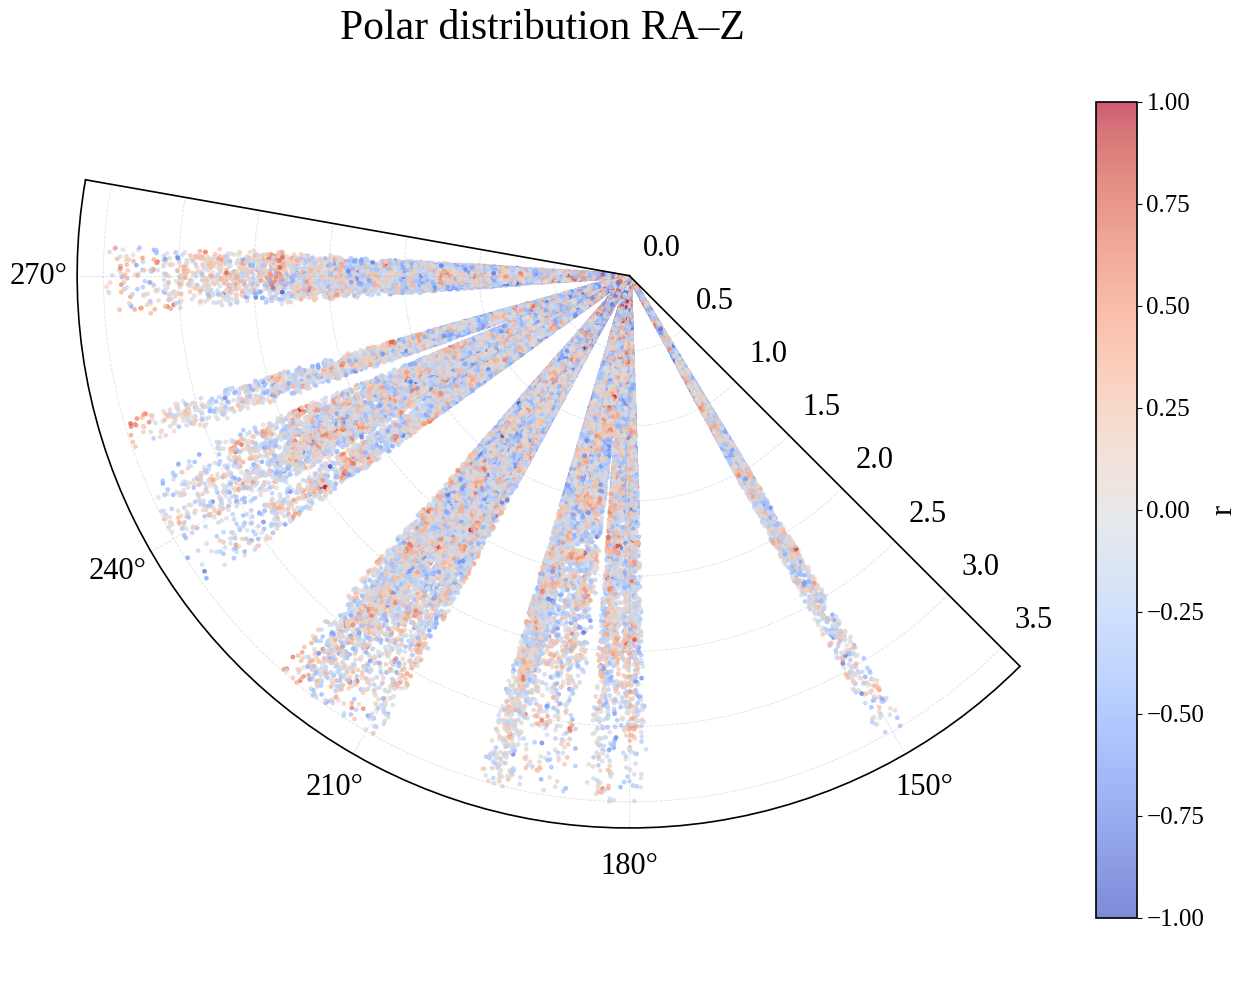

In [14]:
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2

fig = plt.figure(figsize=(14, 12))
ax = plt.subplot(111, projection='polar')

for df_merged in df:
    theta = np.deg2rad(df_merged["RA"])
    r     = df_merged["Z"]
    c     = df_merged["r"]

    sc = ax.scatter(
        theta, r, c=c,
        s=6, alpha=0.65,
        cmap="coolwarm"
    )

ax.set_title("Polar distribution RA–Z", fontsize=30, pad=-5)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetamin(135)
ax.set_thetamax(280)


ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.tick_params(axis='x', pad=17, labelsize=22)
ax.tick_params(axis='y', pad=10, labelsize=22)

cbar = plt.colorbar(sc, pad=0.07, fraction=0.05, shrink=0.8)
cbar.set_label("r", fontsize=22)
cbar.ax.tick_params(labelsize=18)

fig.subplots_adjust(top=0.90, bottom=0.05)

plt.show()


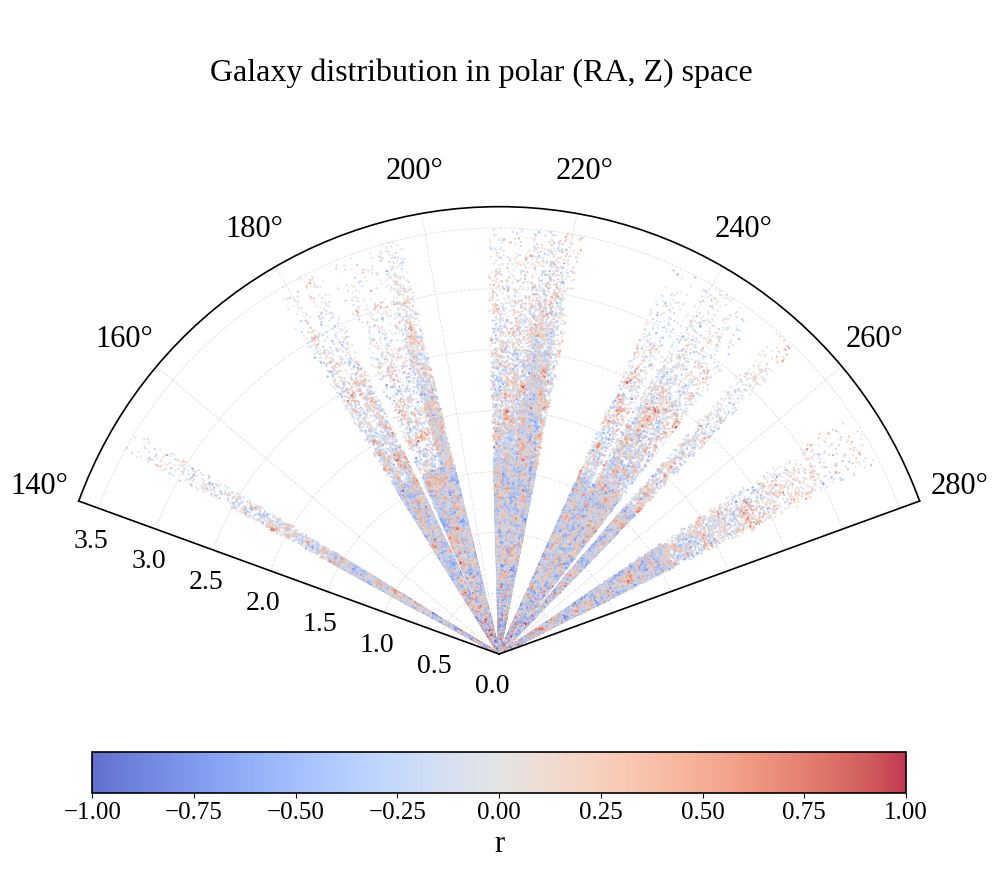

In [15]:
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2

fig = plt.figure(figsize=(14, 12))
ax = plt.subplot(111, projection='polar')

SHIFT = np.deg2rad(210)

for df_merged in df:

    #df_merged = df_mer.sort_values("r", ascending=True)
    theta = np.deg2rad(df_merged["RA"]) - SHIFT
    r     = df_merged["Z"]
    c     = df_merged["r"]
    sc = ax.scatter(theta, r, c=c, s=0.2, alpha=0.8, cmap="coolwarm")

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetamin(-70)
ax.set_thetamax(70)

real_RAs = np.arange(140, 281, 20)
shifted_ticks = np.deg2rad(real_RAs) - SHIFT
ax.set_xticks(shifted_ticks)
ax.set_xticklabels([f"{ra}°" for ra in real_RAs])

fig.suptitle("Galaxy distribution in polar (RA, Z) space",
             y=0.84, fontsize=23)

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.tick_params(axis='x', pad=20, labelsize=22)
ax.tick_params(axis='y', pad=12, labelsize=20)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                    pad=0.01, fraction=0.08, shrink=0.75)

p = cbar.ax.get_position()
cbar.ax.set_position([p.x0, p.y0 + 0.09, p.x1 - p.x0, p.height])

cbar.set_label("r", fontsize=22)
cbar.ax.tick_params(labelsize=18)
#plt.savefig("/Users/soguevaram/Desktop/Research/DESI/Galaxy_distribution_polar.png", dpi=300, bbox_inches='tight')
plt.show()


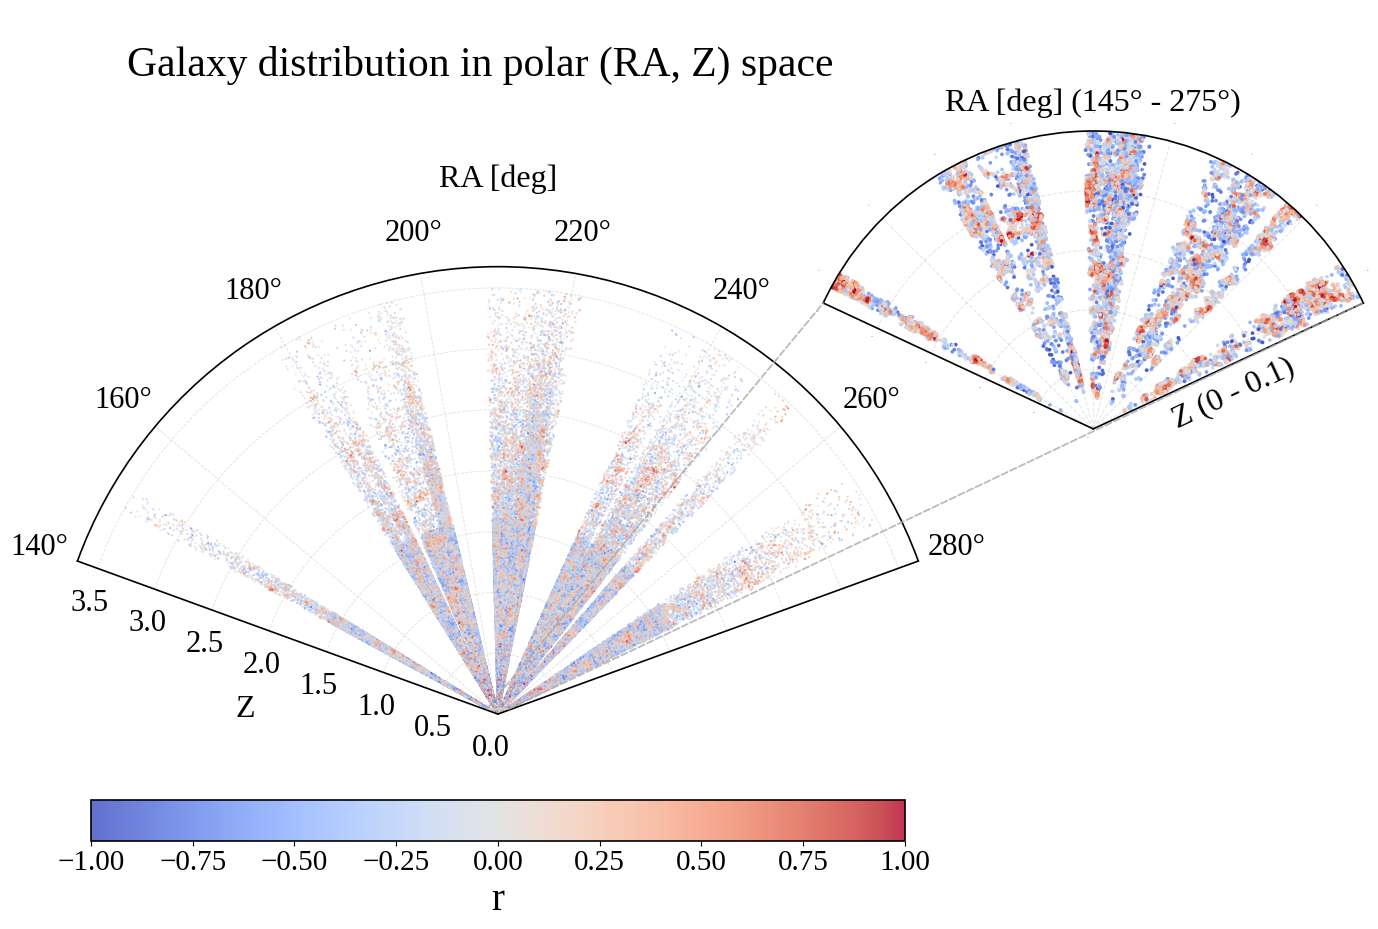

In [16]:
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2

fig = plt.figure(figsize=(14, 12))
ax = plt.subplot(111, projection='polar')

SHIFT = np.deg2rad(210)


for df_merged in df:
    theta = np.deg2rad(df_merged["RA"]) - SHIFT
    r     = df_merged["Z"]
    c     = df_merged["r"]
    sc = ax.scatter(theta, r, c=c, s=0.2, alpha=0.8, cmap="coolwarm")

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_thetamin(-70)
ax.set_thetamax(70)

real_RAs = np.arange(140, 281, 20)
shifted_ticks = np.deg2rad(real_RAs) - SHIFT
ax.set_xticks(shifted_ticks)
ax.set_xticklabels([f"{ra}°" for ra in real_RAs])

fig.suptitle("Galaxy distribution in polar (RA, Z) space",
             y=0.9, fontsize=30)

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

ax.tick_params(axis='x', pad=19, labelsize=22)
ax.tick_params(axis='y', pad=12, labelsize=22)


cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                    pad=0.01, fraction=0.08, shrink=0.75)
p = cbar.ax.get_position()
cbar.ax.set_position([p.x0, p.y0 + 0.1, p.x1 - p.x0, p.height])
cbar.set_label("r", fontsize=28)
cbar.ax.tick_params(labelsize=21)

ra1, ra2 = 145,275
z1, z2 = 0, 0.1


theta1 = np.deg2rad(ra1) - SHIFT
theta2 = np.deg2rad(ra2) - SHIFT

bbox = ax.get_position()

# [left, bottom, width, height]
axins = fig.add_axes(
    [bbox.x1 -0.10, bbox.y1 - 0.4, 0.45, 0.45],
    projection="polar"
)

axins.set_theta_zero_location("N")
axins.set_theta_direction(-1)
axins.grid(True, linestyle="--", alpha=0.3)
rotation = Affine2D().rotate_deg_around(0.5, 0.5, 90)

axins.set_transform(rotation + axins.transAxes)
axins.set_thetamin(np.rad2deg(theta1))
axins.set_thetamax(np.rad2deg(theta2))

# Plot del zoom
for df_merged in df:
    theta = np.deg2rad(df_merged["RA"]) - SHIFT
    r     = df_merged["Z"]
    c     = df_merged["r"]

    mask = (
        (df_merged["RA"] >= ra1) &
        (df_merged["RA"] <= ra2) &
        (df_merged["Z"] >= z1) &
        (df_merged["Z"] <= z2)
    )

    axins.scatter(theta[mask], r[mask], c=c[mask],
                  s=3, alpha=0.85, cmap="coolwarm")

axins.set_xlim(theta1, theta2)
axins.set_ylim(z1, z2)
axins.tick_params(labelsize=0, length=3, width=0.6)
#axins.set_title(f"RA: {ra1} – {ra2}°, Z: {z1} – {z2}", fontsize=15)


rect = Rectangle(
    (theta1, z1),
    theta2 - theta1,
    z2 - z1,
    transform=ax.transData,
    fill=False,
    lw=1.3,
    edgecolor="lightgray"
)
ax.add_patch(rect)


main_pts = [
    (theta1, z2),
    (theta2, z2)
]

zoom_pts = [
    (theta1, z2),
    (theta2, z2)
]

for (xm, ym), (xz, yz) in zip(main_pts, zoom_pts):
    con = ConnectionPatch(
        xyA=(xm, ym), coordsA=ax.transData,
        xyB=(xz, yz), coordsB=axins.transData,
        color="darkgrey",
        linestyle="--",
        lw=1.3,
        alpha=0.8,
        zorder=25
    )
    fig.add_artist(con)

ax.text(0.5, 0.87, "RA [deg]",
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=23)

ax.text(0.2, 0.24, "Z",
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=23)

#plt.savefig("/Users/soguevaram/Desktop/Research/DESI/Galaxy_distribution_polar_zoom_clean.png",dpi=350, bbox_inches='tight')

# ZOOM (RA)
axins.text(
    0.5, 0.8, f"RA [deg] ({ra1}° - {ra2}°)",
    transform=axins.transAxes,
    ha="center", va="bottom",
    fontsize=23
)

# ZOOM (Z)
axins.text(
    0.76, 0.29, f"Z ({z1} - {z2})",
    transform=axins.transAxes,
    ha="center", va="center",
    rotation=25,
    fontsize=23
)

plt.savefig("/Users/soguevaram/Desktop/Research/DESI//plots/redshift_polar.png",dpi=350, bbox_inches='tight')
plt.show()
